# Pune Real Estate Price Prediction

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Algorithms
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

In [2]:
# --- DATA LOADING ---
df = pd.read_csv('dataset.csv')

## 2. PREPROCESSING & FEATURE ENGINEERING

In [3]:
# Handling Skewness in Target Variable
# As identified, Price_Lakhs has a skewness of 2.25. Log transformation is applied.
df['Log_Price'] = np.log1p(df['Price_Lakhs'])

# Splitting Features and Target
X = df.drop(['Price_Lakhs', 'Log_Price'], axis=1)
y = df['Log_Price'] # Training on log-scale for better convergence

# Identifying Column Types
numeric_features = ['BHK', 'Carpet_Area_SqFt', 'Floor_No', 'Parking_Spaces', 'Age_Years']
categorical_features = ['Locality', 'Municipality', 'Property_Type']

## 3. EXPLORATORY DATA ANALYSIS (EDA)

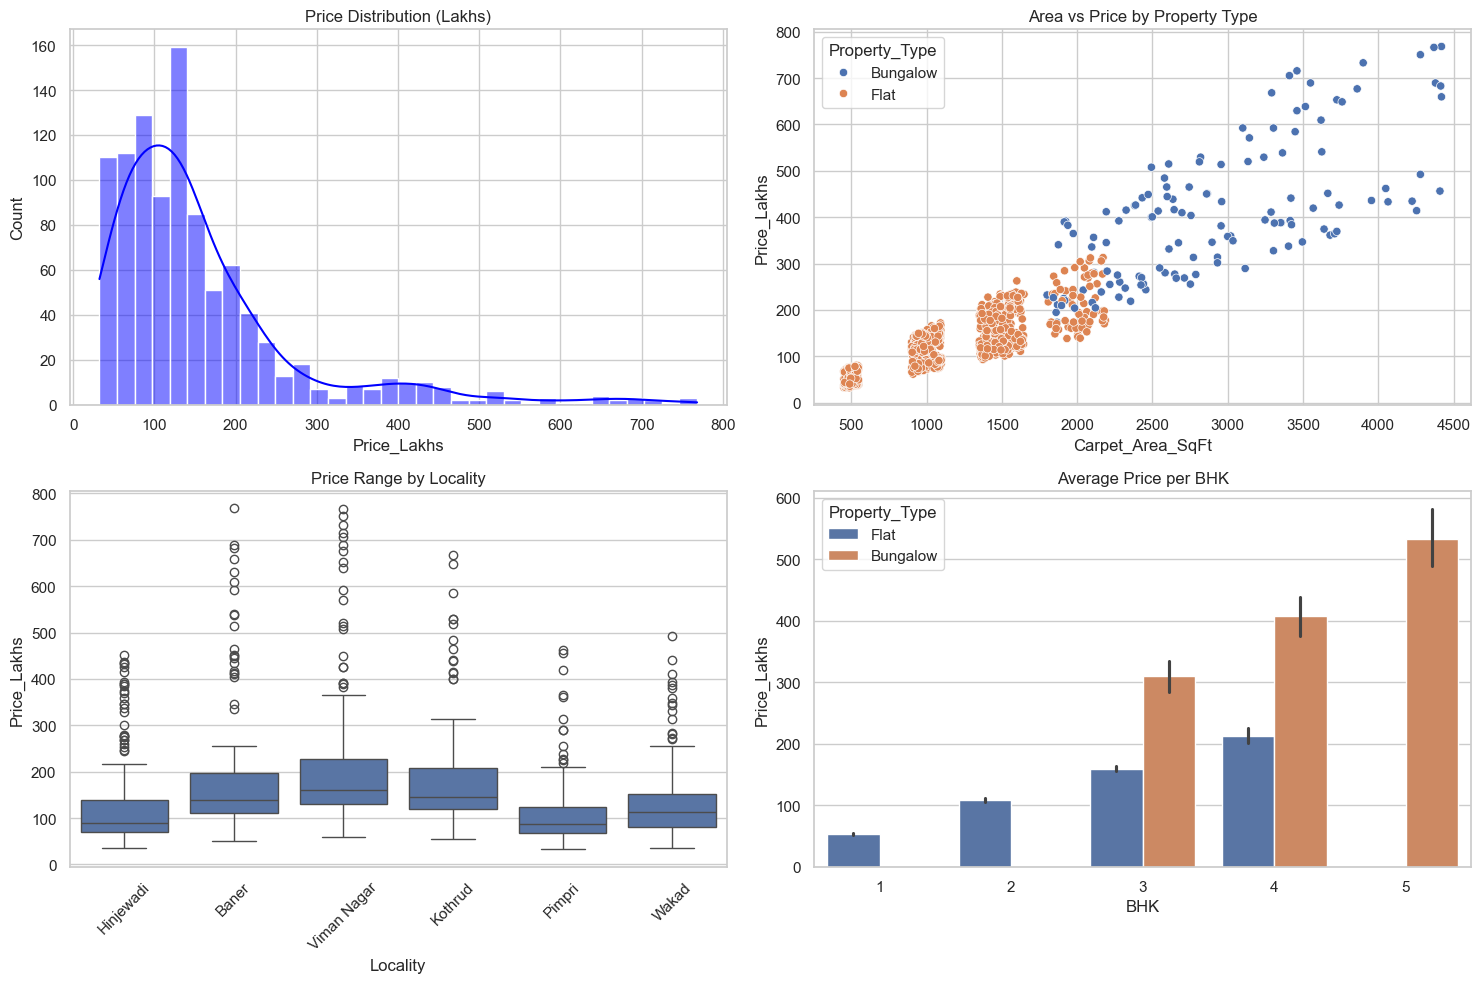

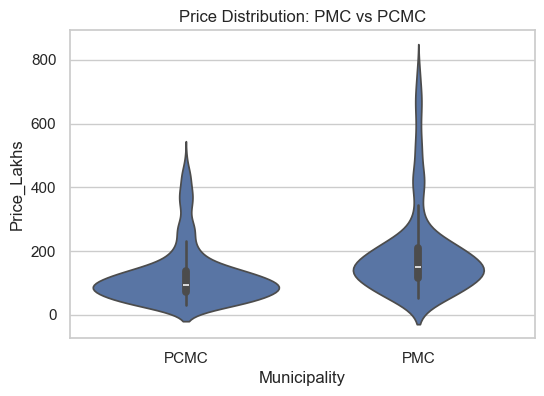

In [4]:
plt.figure(figsize=(15, 10))

# Q1: What is the distribution of property prices in Pune?
plt.subplot(2, 2, 1)
sns.histplot(df['Price_Lakhs'], kde=True, color='blue')
plt.title('Price Distribution (Lakhs)')
# Insight: The distribution is right-skewed, indicating a high concentration of 
# affordable/mid-range housing with a few luxury outliers.

# Q2: How does Carpet Area correlate with Price?
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='Carpet_Area_SqFt', y='Price_Lakhs', hue='Property_Type')
plt.title('Area vs Price by Property Type')
# Insight: Strong linear relationship. Bungalows show a steeper price increase 
# per sq ft compared to flats.

# Q3: Which locality has the highest median price?
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Locality', y='Price_Lakhs')
plt.xticks(rotation=45)
plt.title('Price Range by Locality')
# Insight: Viman Nagar and Kothrud command premium prices compared to PCMC areas.

# Q4: Does the number of BHK impact price significantly across property types?
plt.subplot(2, 2, 4)
sns.barplot(data=df, x='BHK', y='Price_Lakhs', hue='Property_Type')
plt.title('Average Price per BHK')
# Insight: Price grows exponentially with BHK, especially for 4-5 BHK Bungalows.

plt.tight_layout()
plt.show()

# Q5: What is the impact of Municipality on Price?
plt.figure(figsize=(6, 4))
sns.violinplot(data=df, x='Municipality', y='Price_Lakhs')
plt.title('Price Distribution: PMC vs PCMC')
plt.show()
# Insight: PMC areas generally have a higher ceiling for luxury prices.

## 4. PIPELINE SETUP (Encoding & Scaling)

In [5]:
# Preprocessing for numerical data: Standardization
# Preprocessing for categorical data: One-Hot Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

## 5. MODEL BUILDING & HYPERPARAMETER TUNING

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

# Parameter grids for tuning
param_grids = {
    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1]
    }
}

results = []

print("### Model Performance Evaluation")

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('model', model)])
    
    if name in param_grids:
        grid_search = GridSearchCV(pipeline, param_grids[name], cv=3, scoring='r2')
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
    else:
        best_model = pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred_log = best_model.predict(X_test)
    
    # Revert Log transformation for metrics
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)
    
    # Metrics
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    r2 = r2_score(y_test_real, y_pred_real)
    
    results.append({
        'Model': name,
        'MAE (Lakhs)': mae,
        'RMSE (Lakhs)': rmse,
        'R2 Score': r2
    })

### Model Performance Evaluation


## 6. COMPARISON & BEST MODEL SELECTION

               Model  MAE (Lakhs)  RMSE (Lakhs)  R2 Score
4            XGBoost     3.021055      5.037238  0.997889
3  Gradient Boosting     3.823847      6.893437  0.996046
2      Random Forest     4.441665      7.398235  0.995445
1              Ridge    16.186069     32.402045  0.912633
0  Linear Regression    16.224727     32.568961  0.911730


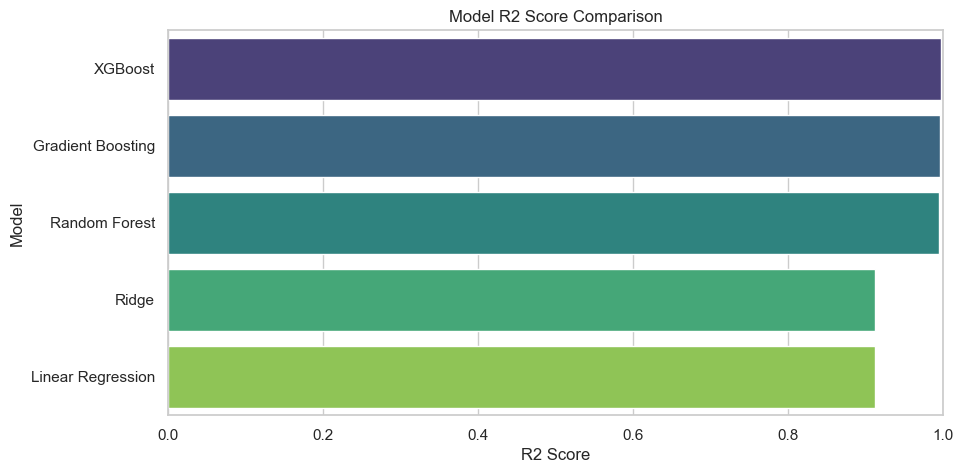

The Best Model is: XGBoost
Model exported successfully as pune_real_estate_model.pkl


In [7]:
comparison_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
print(comparison_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='R2 Score', y='Model', palette='viridis')
plt.title('Model R2 Score Comparison')
plt.xlim(0, 1)
plt.show()

# --- 6. EXPORTING THE BEST MODEL ---
# Selecting XGBoost as it typically performs best on structured data
best_model_name = comparison_df.iloc[0]['Model']
print(f"The Best Model is: {best_model_name}")

import joblib
# Re-training the best model pipeline on full data for export
final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('model', XGBRegressor(n_estimators=200, learning_rate=0.1))])
final_pipeline.fit(X, y)

joblib.dump(final_pipeline, 'pune_real_estate_model.pkl')
print("Model exported successfully as pune_real_estate_model.pkl")